In [1]:
# from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import time
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
#import csv
import os.path
from os import path
from numpy.matlib import repmat
%matplotlib inline
from preprocess import preprocessing as pre
from sklearn.decomposition import PCA


In [2]:
from preprocess import *

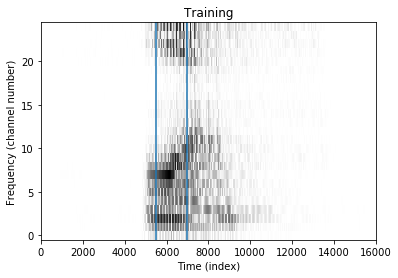

In [3]:
testSounds = ["0a196374_nohash_1"]
trainingSounds = ["0a196374_nohash_1"]

cfN = 25    #this is typically 50, but due to 50 testAudio, we lowered 
scale = 15  #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample

trainingSpect = pre.spectArray(trainingSounds[0], cfN=cfN)
t_start = 5000
t_end = 10000
t_step = 100 #decrease bc too course

trainingIndex = [5500,7000]  #attempt with single trainingIndex
testingIndex = [x for x in range(t_start,t_end,t_step)] #[5000;10000;100]
range_f = 100 
step_f = 20    #used to be 10, but we are using coarser signals to speed computation
#range in times of frequencies
lenTraining = len(trainingSounds) * len(trainingIndex)
lenTest = len(testSounds) * len(testingIndex)

pre.spectShow(trainingSpect)
plt.title("Training")
plt.axvline(x=trainingIndex[0])
plt.axvline(x=trainingIndex[1])

In [4]:
len(testingIndex)

50

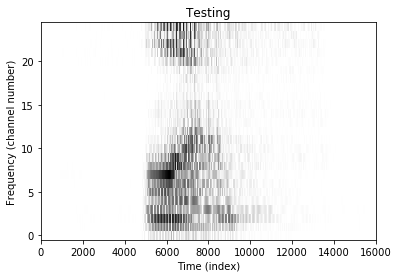

In [5]:
colors = ['y','k','b','y','k','b','y','k','b','y']

for sound in trainingSounds:
    for i in trainingIndex:
        if i == trainingIndex[0]:
            trainingAudio = pre.chooseSound(pre.spectArray(sound, cfN=cfN), range_f, step_f, i, scale);
        else:
            trainingAudio = np.concatenate((trainingAudio, pre.chooseSound(pre.spectArray(sound,cfN=cfN), range_f, step_f, i, scale)))

testAudio = np.array([])


testingSpect = pre.spectArray(testSounds[0], cfN=cfN)  #pull out of the loop (before loop)
pre.spectShow(testingSpect)
plt.title("Testing")


for index in testingIndex: #index in testingIndex
   # plt.axvline(x=index, c=colors[testingIndex.index(index)])
    
    if testAudio.shape[0] == 0:
        testAudio = pre.chooseSound(testingSpect, range_f, step_f, index,scale)
    else:
        testAudio = np.concatenate((testAudio,pre.chooseSound(testingSpect, range_f, step_f, index,scale)))


In [6]:
testAudio.shape

(50L, 125L)

In [7]:
pca = PCA(n_components = 50, whiten = False)
pca.fit(testAudio)

PCA(copy=True, iterated_power='auto', n_components=50, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [8]:
from lib import epl
nGammaPerTraining = 10
nGammaPerSound = 10 
print("Number of sounds to train = " + str(len(trainingAudio))); 
print("Number of sounds to test = " + str(len(testAudio))); 

#Network initialization
nMCs = len(trainingAudio[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*lenTraining;     #every MC has 5 GCs per sound  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(sound, learn_flag=0, nGammaPerSound=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(sound); 
    for j in range(0, nGammaPerSound):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingAudio)):
    print("Training sound " + str(i+1)) 
    sniff(trainingAudio[i], learn_flag=1,nGammaPerSound = nGammaPerTraining); 
    # changed nGammaPerSound from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, len(trainingAudio)):
    sniff(trainingAudio[i], learn_flag=0, nGammaPerSound = nGammaPerSound);
    
#Testing
for i in range(0, len(testAudio)):
    sniff(testAudio[i], learn_flag=0, nGammaPerSound = nGammaPerSound); 
    if((i+1)%10==0 and (i+1)!=0):
        print(str(i+1) + " sounds tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")


Number of sounds to train = 2
Number of sounds to test = 50
Training sound 1
Training sound 2
10 sounds tested
20 sounds tested
30 sounds tested
40 sounds tested
50 sounds tested
Simulation Duration = 803.325000048s


## epl gammaCode parsing

In [9]:
#Remember the first training loop uses nGammaPerSound = 10

gammaCode_size = lenTraining*(nGammaPerTraining + nGammaPerSound) + lenTest * nGammaPerSound
(gammaCode_size,len(epl.gammaCode))

(540, 540)

In [10]:
(len(epl.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)]),len(epl.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)][0]))

(20, 125)

In [11]:
(nGammaPerSound, lenTraining, -1)

(10, 2, -1)

In [12]:
trained = np.array(epl.gammaCode[lenTraining*nGammaPerTraining:lenTraining*(nGammaPerTraining+nGammaPerSound)]).reshape(nGammaPerSound, lenTraining, -1)
#put lenTest/nGammaPerSound into another variable
tested = np.array(epl.gammaCode[lenTraining*(nGammaPerTraining+nGammaPerSound):]).reshape(nGammaPerSound, lenTest, -1)

In [13]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((lenTraining, lenTest), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (pre.computeSimilarity(trained[-1][i], tested[-1][j]))
        #index -1 is the last activation of the gamma cycle which is the most different one
decisionMatrix = (SImatrix> 0.75)

In [14]:
trained[5][0] == trained[5][1]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [15]:
trained.shape

(10L, 2L, 125L)

In [16]:
for j in range(0, len(tested[-1])):
    print(tested[-1][2]==tested[-1][j])

[ True False  True  True False  True  True  True False False False False
 False  True False False False  True False False  True False  True False
 False  True False  True False  True  True False False False False False
 False False  True False  True  True False  True  True False False False
 False False False  True False  True False  True False False False  True
 False  True  True  True  True  True False False False False  True False
 False  True  True False False  True False  True False False  True  True
  True  True  True  True  True  True False False  True False False  True
  True False  True False  True False False False False False False False
  True False False False  True  True False False False False  True  True
  True False False False False]
[ True False False False False  True  True  True  True False False  True
  True  True False False False  True  True False  True False  True  True
 False  True False False False False  True False False  True  True  True
 False  True  True 

In [17]:
#designing truth Table
truthTable = np.tile([True, False], (lenTest,1)).T

In [18]:
truthTable

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]])

In [19]:
decisionMatrix

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]])

In [20]:
SImatrix

array([[0.1013, 0.1111, 0.1062, 0.1062, 0.1062, 0.1062, 0.1062, 0.1062,
        0.1062, 0.1062, 0.1111, 0.1111, 0.1013, 0.0965, 0.0965, 0.087 ,
        0.0917, 0.0965, 0.0917, 0.0917, 0.1013, 0.0917, 0.0823, 0.0965,
        0.0917, 0.1111, 0.1062, 0.1062, 0.1062, 0.1062, 0.0776, 0.1013,
        0.0776, 0.087 , 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917,
        0.0638, 0.0776, 0.0917, 0.0776, 0.0823, 0.0917, 0.0917, 0.0917,
        0.0917, 0.0917],
       [0.1013, 0.1111, 0.1062, 0.1062, 0.1062, 0.1062, 0.1062, 0.1062,
        0.1062, 0.1062, 0.1111, 0.1111, 0.1013, 0.0965, 0.0965, 0.087 ,
        0.0917, 0.0965, 0.0917, 0.0917, 0.1013, 0.0917, 0.0823, 0.0965,
        0.0917, 0.1111, 0.1062, 0.1062, 0.1062, 0.1062, 0.0776, 0.1013,
        0.0776, 0.087 , 0.0917, 0.0917, 0.0917, 0.0917, 0.0917, 0.0917,
        0.0638, 0.0776, 0.0917, 0.0776, 0.0823, 0.0917, 0.0917, 0.0917,
        0.0917, 0.0917]])

In [21]:
decisionMatrix== truthTable[0]

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]])

In [22]:
pre.results(decisionMatrix,truthTable)

(50, 50)

ValueError: x and y must have same first dimension, but have shapes (5L,) and (50L, 2L)

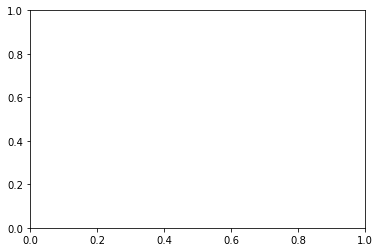

In [23]:
plt.plot(range(1,6) , SImatrix.T, ".") 
